In [1]:
import numpy as np
import scipy.io
import jax.numpy as jnp
import os
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Import the cla-sses from your parametanet.py file
from parametanet_real import (
    NetworkState,
    BoundarySequence,
    NetworkParameters,
    to_para_network,
    rollout_simulation,
)


In [5]:
def load_and_prepare_metanet_data(mat_filepath: str):
    """
    Reads Input_data.mat, interpolates the data, and constructs JAX objects.
    """
    data = scipy.io.loadmat(mat_filepath)

    # Extract arrays
    On_ramp_flow = data["On_ramp_flow"]
    Off_ramp_rate = data["Off_ramp_rate"]
    Boundary_mainstream = data["Boundary_mainstream"]
    Initial_mainstream_speed = data["Initial_mainstream_speed"].flatten()
    Initial_mainstream_flow = data["Initial_mainstream_flow"].flatten()

    # Time Configuration
    Tm, Tsim = 60, 5
    Starting_time = 0
    Ending_time = 3 * 3600 + 59 * 60 + 0

    time_mis = np.arange(Starting_time, Ending_time + Tm, Tm)
    time_sim = np.arange(Starting_time, Ending_time + Tsim, Tsim)
    K = len(time_sim) - 1

    def interpolate_data(meas_time, meas_data, sim_time):
        f = interp1d(meas_time, meas_data, axis=0, fill_value="extrapolate")
        return f(sim_time)

    On_ramp_flow_Interp = interpolate_data(time_mis, On_ramp_flow, time_sim)
    Off_ramp_rate_Interp = interpolate_data(time_mis, Off_ramp_rate, time_sim)
    Boundary_mainstream_Interp = interpolate_data(time_mis, Boundary_mainstream, time_sim)

    # Network Configuration
    N = 21
    L_meters = np.array([433, 437, 444, 441, 463, 450, 450, 448, 306, 340, 350, 424, 566, 706, 658, 424, 419, 432, 413, 427, 426])
    L_km = L_meters / 1000.0
    lambda_lanes = np.array([3] * 8 + [2] * 13)
    lane_N_plus_1 = 2
    delta_lambda = np.append(lambda_lanes[:-1] - lambda_lanes[1:], lambda_lanes[-1] - lane_N_plus_1)

    # --- THE DTYPE FIX IS HERE ---
    v_init = Initial_mainstream_speed
    q_init = Initial_mainstream_flow
    rho_init = q_init / (v_init * lambda_lanes)

    initial_state = NetworkState(
        density=jnp.array(rho_init, dtype=jnp.float32), 
        flow=jnp.array(q_init, dtype=jnp.float32), 
        speed=jnp.array(v_init, dtype=jnp.float32)
    )
    # -----------------------------

    # Boundaries
    q_0 = Boundary_mainstream_Interp[:, 0]
    v_0 = Boundary_mainstream_Interp[:, 1]
    q_N_plus_1 = Boundary_mainstream_Interp[:, 2]
    v_N_plus_1 = Boundary_mainstream_Interp[:, 3]
    rho_N_plus_1 = q_N_plus_1 / (v_N_plus_1 * lane_N_plus_1)

    r_matrix = np.zeros((len(time_sim), N))
    r_matrix[:, 9] = On_ramp_flow_Interp[:, 0]
    r_matrix[:, 15] = On_ramp_flow_Interp[:, 1]

    s_matrix = np.zeros((len(time_sim), N))
    s_matrix[:, 7] = Off_ramp_rate_Interp[:, 0]
    s_matrix[:, 13] = Off_ramp_rate_Interp[:, 1]

    boundaries = BoundarySequence(
        q_0=jnp.array(q_0[:-1], dtype=jnp.float32),
        v_0=jnp.array(v_0[:-1], dtype=jnp.float32),
        rho_N_plus_1=jnp.array(rho_N_plus_1[:-1], dtype=jnp.float32),
        r=jnp.array(r_matrix[:-1, :], dtype=jnp.float32),
        s=jnp.zeros((K, N), dtype=jnp.float32), 
        s_rate=jnp.array(s_matrix[:-1, :], dtype=jnp.float32),  
    )

    # Parameters
    params = NetworkParameters(
        T=Tsim / 3600.0,
        L=jnp.array(L_km, dtype=jnp.float32),
        lambda_=jnp.array(lambda_lanes, dtype=jnp.float32),
        delta_lambda=jnp.array(delta_lambda, dtype=jnp.float32),
        tau=10.24 / 3600.0,
        nu=8.96,
        kappa=10.0,
        delta=2.92,
        phi=0.0001346,
        alpha=jnp.array([1.61] * N, dtype=jnp.float32),
        critical_density=jnp.array([36.69] * N, dtype=jnp.float32),
        free_flow_speed=jnp.array([117.0] * N, dtype=jnp.float32),
    )

    return initial_state, boundaries, params, time_sim

In [6]:
# 1. Look for the file in the current notebook directory
mat_filepath = os.path.join(os.getcwd(), "Input_data.mat")

# 2. Load the data
initial_state, boundaries, original_params, time_sim = load_and_prepare_metanet_data(mat_filepath)

# 3. Convert parameters to JAX format
para_params = to_para_network(original_params)

# 4. Run the simulation (The first time this runs, JAX will compile it. Subsequent runs will be instant).
print("Compiling and running JAX simulation rollout...")
trajectory = rollout_simulation(initial_state, boundaries, para_params)

print("Simulation Complete!")
print(f"Final shape of density matrix: {trajectory.density.shape}")

Compiling and running JAX simulation rollout...
Simulation Complete!
Final shape of density matrix: (2868, 21)


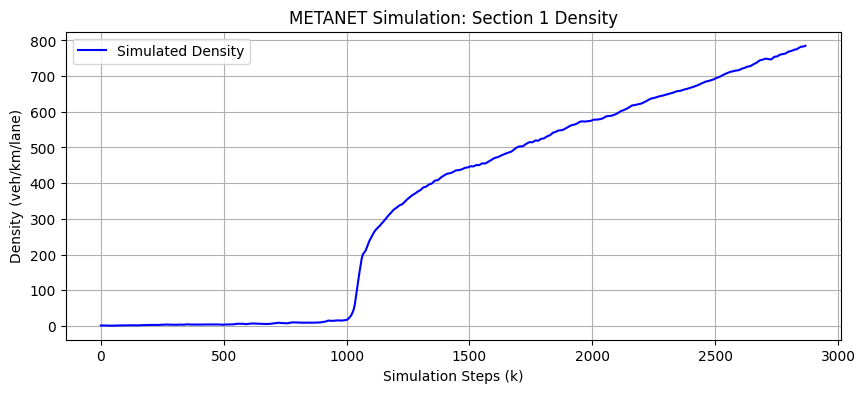

In [7]:
# Recreate the first figure from provafig.m (Section 1 Density)
section_idx = 0  # Section 1 (0-indexed in Python)

plt.figure(figsize=(10, 4))
plt.plot(trajectory.density[:, section_idx], label="Simulated Density", color="blue")
plt.title(f"METANET Simulation: Section {section_idx + 1} Density")
plt.xlabel("Simulation Steps (k)")
plt.ylabel("Density (veh/km/lane)")
plt.legend()
plt.grid(True)
plt.show()


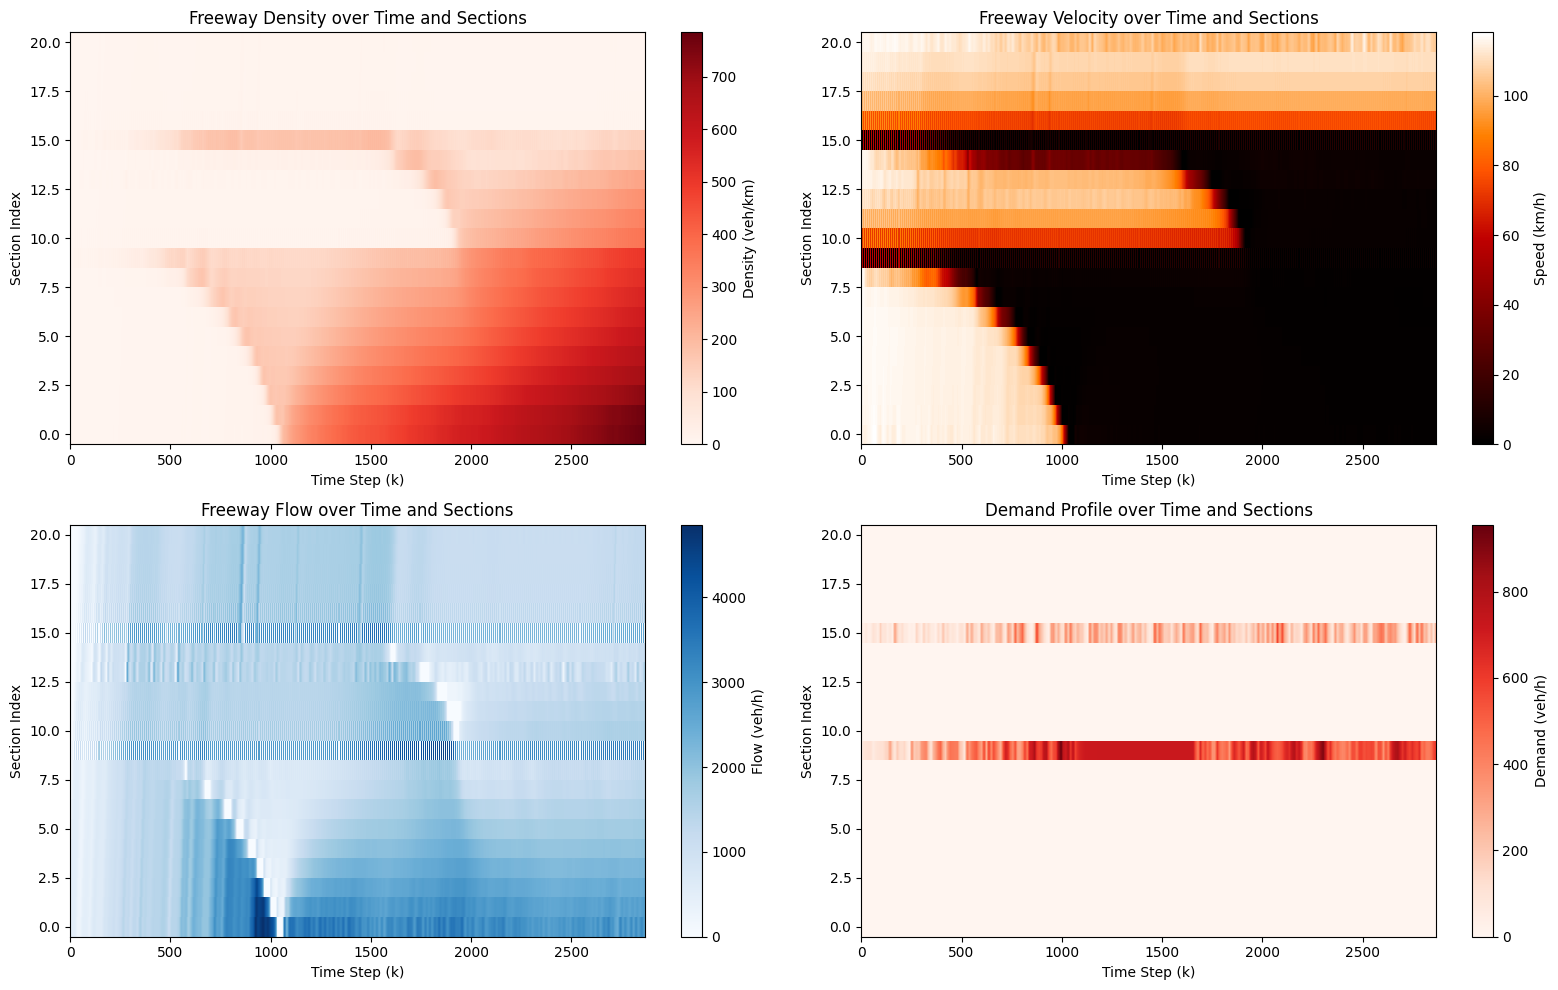

In [10]:
def plot_trajectories(traj, dem, N: int, K: int):
    density_res = np.array(traj.density)
    speed_res = np.array(traj.speed)
    flow_res = np.array(traj.flow)
    time_grid, section_grid = np.meshgrid(np.arange(K), np.arange(N))

    # Create a 2x2 grid of subplots in one large figure
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Density Plot (Top-Left)
    mesh1 = axs[0, 0].pcolormesh(
        time_grid, section_grid, density_res.T, cmap="Reds", shading="auto"
    )
    axs[0, 0].set_title("Freeway Density over Time and Sections")
    axs[0, 0].set_xlabel("Time Step (k)")
    axs[0, 0].set_ylabel("Section Index")
    fig.colorbar(mesh1, ax=axs[0, 0], label="Density (veh/km)")

    # 2. Velocity Plot (Top-Right)
    mesh2 = axs[0, 1].pcolormesh(
        time_grid, section_grid, speed_res.T, cmap="gist_heat", shading="auto"
    )
    axs[0, 1].set_title("Freeway Velocity over Time and Sections")
    axs[0, 1].set_xlabel("Time Step (k)")
    axs[0, 1].set_ylabel("Section Index")
    fig.colorbar(mesh2, ax=axs[0, 1], label="Speed (km/h)")

    # 3. Flow Plot (Bottom-Left)
    mesh3 = axs[1, 0].pcolormesh(
        time_grid, section_grid, flow_res.T, cmap="Blues", shading="auto"
    )
    axs[1, 0].set_title("Freeway Flow over Time and Sections")
    axs[1, 0].set_xlabel("Time Step (k)")
    axs[1, 0].set_ylabel("Section Index")
    fig.colorbar(mesh3, ax=axs[1, 0], label="Flow (veh/h)")

    # 4. Demand Plot (Bottom-Right)
    mesh4 = axs[1, 1].pcolormesh(
        time_grid, section_grid, dem.T, cmap="Reds", shading="auto"
    )
    axs[1, 1].set_title("Demand Profile over Time and Sections")
    axs[1, 1].set_xlabel("Time Step (k)")
    axs[1, 1].set_ylabel("Section Index")
    fig.colorbar(mesh4, ax=axs[1, 1], label="Demand (veh/h)")

    plt.tight_layout()  # Ensures labels and colorbars don't overlap
    plt.show()
plot_trajectories(trajectory, boundaries.r, N=21, K=trajectory.density.shape[0])

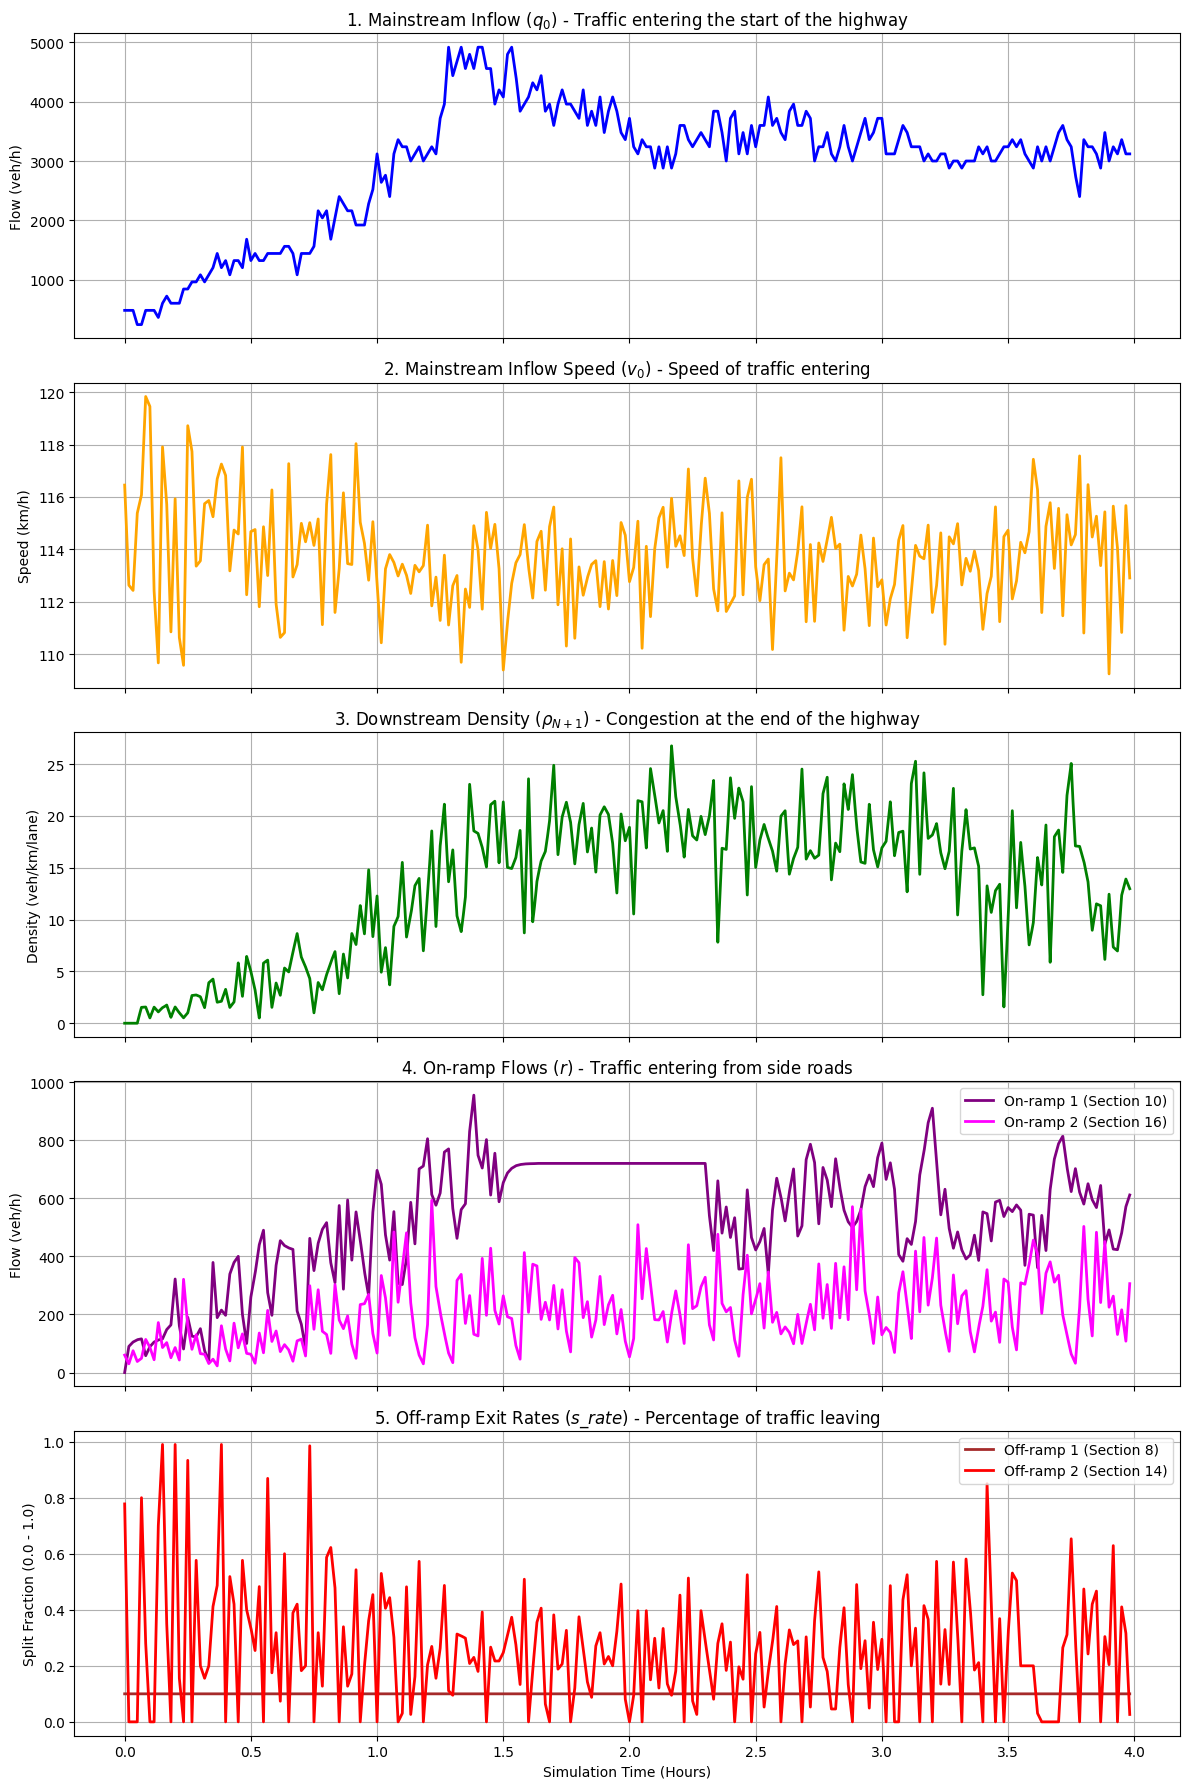

In [11]:
import matplotlib.pyplot as plt

# Convert simulation time from seconds to hours for a cleaner X-axis
# time_sim has K+1 elements, so we slice [:-1] to match the K steps in the boundary arrays
time_hours = time_sim[:-1] / 3600.0

# Create a large figure with 5 subplots stacked vertically
fig, axs = plt.subplots(5, 1, figsize=(12, 18), sharex=True)

# 1. Mainstream Inflow (q_0)
axs[0].plot(time_hours, boundaries.q_0, color='blue', linewidth=2)
axs[0].set_title('1. Mainstream Inflow ($q_0$) - Traffic entering the start of the highway')
axs[0].set_ylabel('Flow (veh/h)')
axs[0].grid(True)

# 2. Mainstream Inflow Speed (v_0)
axs[1].plot(time_hours, boundaries.v_0, color='orange', linewidth=2)
axs[1].set_title('2. Mainstream Inflow Speed ($v_0$) - Speed of traffic entering')
axs[1].set_ylabel('Speed (km/h)')
axs[1].grid(True)

# 3. Downstream Density (rho_N_plus_1)
axs[2].plot(time_hours, boundaries.rho_N_plus_1, color='green', linewidth=2)
axs[2].set_title('3. Downstream Density ($\\rho_{N+1}$) - Congestion at the end of the highway')
axs[2].set_ylabel('Density (veh/km/lane)')
axs[2].grid(True)

# 4. On-ramp Flows (r)
# Your MATLAB code places on-ramps at Python indices 9 (Section 10) and 15 (Section 16)
axs[3].plot(time_hours, boundaries.r[:, 9], label='On-ramp 1 (Section 10)', color='purple', linewidth=2)
axs[3].plot(time_hours, boundaries.r[:, 15], label='On-ramp 2 (Section 16)', color='magenta', linewidth=2)
axs[3].set_title('4. On-ramp Flows ($r$) - Traffic entering from side roads')
axs[3].set_ylabel('Flow (veh/h)')
axs[3].legend()
axs[3].grid(True)

# 5. Off-ramp Rates (s_rate)
# Your MATLAB code places off-ramps at Python indices 7 (Section 8) and 13 (Section 14)
axs[4].plot(time_hours, boundaries.s_rate[:, 7], label='Off-ramp 1 (Section 8)', color='brown', linewidth=2)
axs[4].plot(time_hours, boundaries.s_rate[:, 13], label='Off-ramp 2 (Section 14)', color='red', linewidth=2)
axs[4].set_title('5. Off-ramp Exit Rates ($s\\_rate$) - Percentage of traffic leaving')
axs[4].set_ylabel('Split Fraction (0.0 - 1.0)')
axs[4].set_xlabel('Simulation Time (Hours)')
axs[4].legend()
axs[4].grid(True)

plt.tight_layout()
plt.show()